In [15]:
import json
import os

from matplotlib import pyplot as plt
import cv2

from src.gait_analysis.data_cleaning.data_smoothing import (
    get_valid_frames,
    flatten_pose_data,
    acceleration,
    remove_outliers,
    apply_butterworth,
)

In [16]:
overlay_path = (
    "../data/output/tuned_yolo_overlays/outdoor/RES1080_FPS60_LENlinear/v1_overlay.mp4"
)
pose_model_output_path = (
    "../data/output/tuned_yolo/outdoor/RES1080_FPS60_LENlinear/v1.json"
)

In [17]:
cap = cv2.VideoCapture(overlay_path)
FPS = cap.get(cv2.CAP_PROP_FPS)

In [18]:
with open(os.path.join(pose_model_output_path), "r") as f:
    pose_model_output = json.load(f)

connections = pose_model_output["connections"]
pose_data = pose_model_output["pose_data"]

In [19]:
keypoints = list(set([x for xs in connections for x in xs]))

# 1. Valid Frames

only consider the frames between the first and the last "valid" frames. A valid frame is frame that has each keypoint detected.

In [20]:
keys_to_exclude = {"raw_keypoints"}

valid_indices = get_valid_frames(pose_data, keypoints)

pose_data = flatten_pose_data(
    pose_data[valid_indices[0] : valid_indices[-1]], keys_to_exclude=keys_to_exclude
)

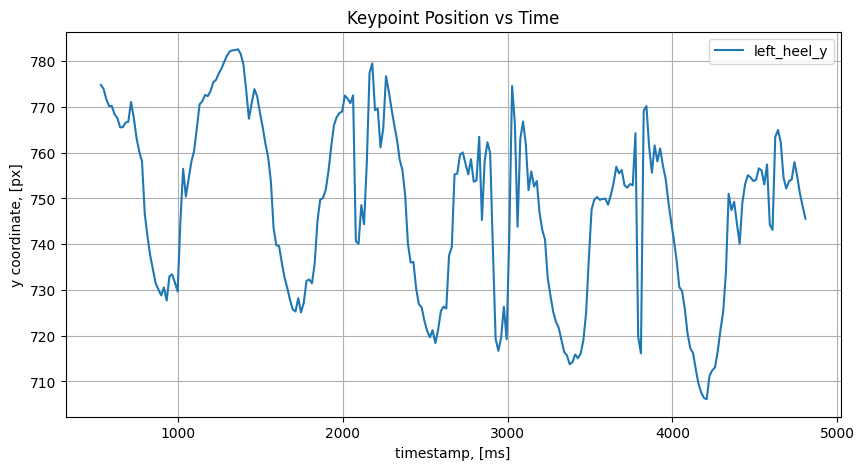

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

pose_data.plot(
    x="timestamp_ms",
    y="left_heel_y",
    ax=ax,
    ylabel="y coordinate, [px]",
    xlabel="timestamp, [ms]",
    title="Keypoint Position vs Time",
    grid=True,
);

# 2. Outlier Removal

outliers are detected based on keypoint changes in position along both axes. Changes too rapid are unnatural. We calculate acceleration using the raw y-coordinates and then remove the points, where the absolute acceleration value is larger than q3 + 1.5*iqr, iqr = q3 - q1, q1 and q3 being the 0.25 and 0.75 quantiles accordingly.



In [22]:
acceleration_df = acceleration(pose_data, fps=FPS)

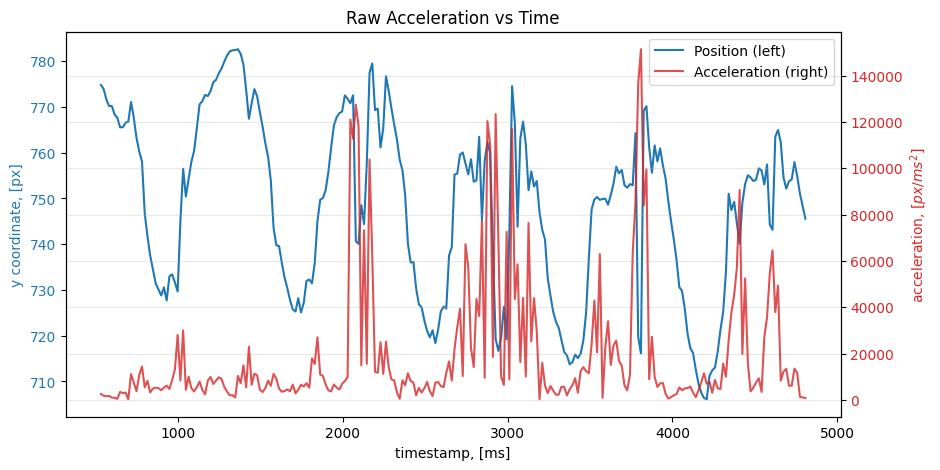

In [23]:
fig, ax1 = plt.subplots(figsize=(10, 5))

pose_data.plot(
    x="timestamp_ms", y="left_heel_y", ax=ax1, color="tab:blue", label="Position (left)"
)
ax1.set_ylabel("y coordinate, [px]", color="tab:blue")
ax1.set_xlabel("timestamp, [ms]")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()

acceleration_df.plot(
    x="timestamp_ms",
    y="left_heel_y",
    ax=ax2,
    color="tab:red",
    label="Acceleration (right)",
    alpha=0.8,
)
ax2.set_ylabel("acceleration, [$px/{ms}^2$]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax2.get_legend().remove()

plt.title("Raw Acceleration vs Time")
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
pose_data_no_outliers = remove_outliers(acceleration_df, pose_data)

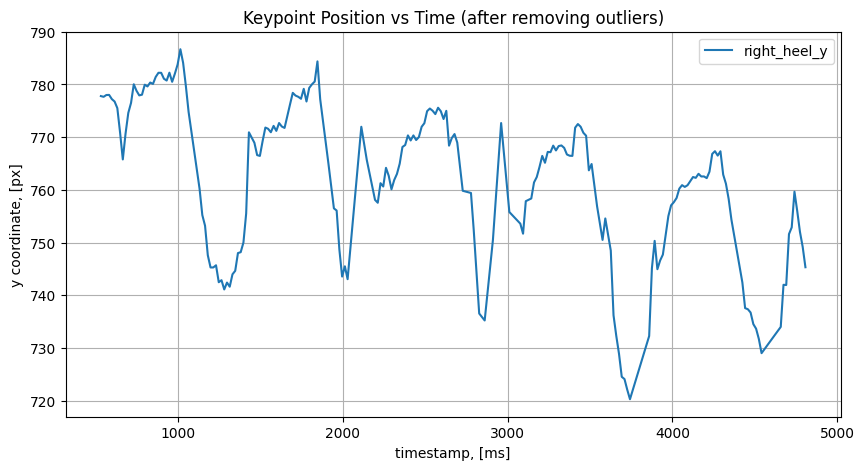

In [25]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

pose_data_no_outliers.plot(
    x="timestamp_ms",
    y="right_heel_y",
    ax=ax,
    ylabel="y coordinate, [px]",
    xlabel="timestamp, [ms]",
    title="Keypoint Position vs Time (after removing outliers)",
    grid=True,
);

# 3. Smoothing

butterworth filter to smooth the data.

In [26]:
smooth_pose_data = apply_butterworth(pose_data_no_outliers, fps=FPS, cutoff=4.0)

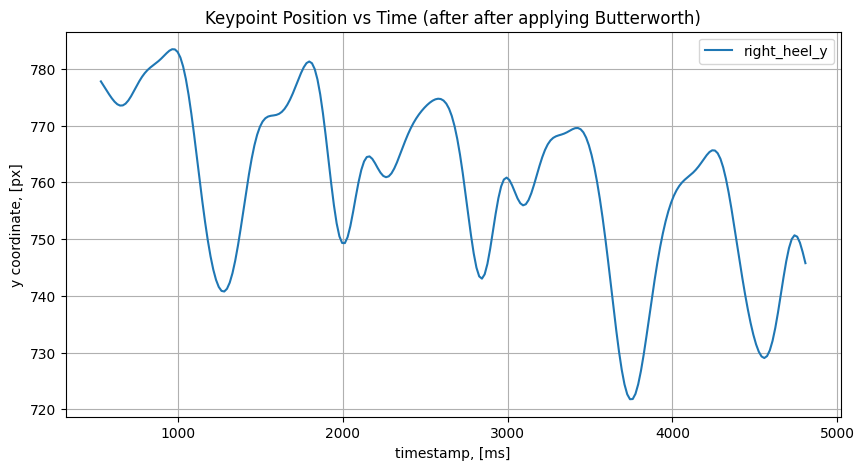

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 5))

smooth_pose_data.plot(
    x="timestamp_ms",
    y="right_heel_y",
    ylabel="y coordinate, [px]",
    xlabel="timestamp, [ms]",
    title="Keypoint Position vs Time (after after applying Butterworth)",
    ax=ax1,
    grid=True,
);